# My code

In [ ]:
from pathlib import Path
import sys
from importlib import reload

project_root = Path.cwd()
if not (project_root / "utils").exists():
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import utils.utils as utils
reload(utils)

<module 'utils.utils' from 'h:\\Project\\traffic-hope-network\\utils\\utils.py'>

In [ ]:
model_id = "Qwen/Qwen3-4B"
attn_implementation = "eager"

model, tokenizer = utils.load_model_and_tokenizer(model_id, attn_implementation)

In [ ]:
gen_kwargs = {
    'max_new_tokens': 512,
    'temperature': 0.7,

}
prompt = r"Natalia sold clips to 48 of her friends in April, and then she sold half as many clips in May. How many clips did Natalia sell altogether in April and May? Given the ground truth answer is $\boxed{72}$. Notice that do not leak the ground truth answer in your reasoning and final answer"
prompt = utils.build_prompt(tokenizer, "", prompt, encode=False, add_generation_prompt=True, enable_thinking=True)

full_ids, generated_text = utils.generate_and_concate(model, tokenizer, prompt, **gen_kwargs)

h:\miniconda3\envs\LGM\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading checkpoint shards: 100%|██████████| 3/3 [00:08<00:00,  2.88s/it]
Some parameters are on the meta device because they were offloaded to the disk and cpu.


In [ ]:
# Optional if you want to custom the model's generation output

prompt = r"Natalia sold clips to 48 of her friends in April, and then she sold half as many clips in May. How many clips did Natalia sell altogether in April and May? Given the ground truth answer is $\boxed{72}$. Notice that do not leak the ground truth answer in your reasoning and final answer"
prompt = utils.build_prompt(tokenizer, "", prompt, encode=False, add_generation_prompt=True, enable_thinking=True)
generated_text = "<think>\nOkay, let's see. Natalia sold clips to 48 friends in April. Then in May, she sold half as many. So I need to figure out how many she sold in May first. Half of 48 would be 24, right? Because 48 divided by 2 is 24. So in May, she sold 24 clips. Then to find the total for both months, I add April and May together. That would be 48 plus 24. Let me check that again. 48 plus 24... 40 plus 20 is 60, and 8 plus 4 is 12, so 60 plus 12 is 72. So the total number of clips she sold is 72. Wait, the ground truth answer is 72, but I shouldn't mention that. But according to my calculation, that's correct. Let me just make sure I didn't make a mistake. April is 48, May is half of that, which is 24. 48 +24 is indeed 72. Yeah, that seems right.\n</think>\n\nNatalia sold 48 clips in April. In May, she sold half as many, which is $ \\frac{48}{2} = 24 $ clips. Adding the clips sold in both months:  \n$ 48 + 24 = 72 $.  \n\nThus, Natalia sold **72** clips altogether in April and May.  \n\n$\\boxed{72}$"
full_ids = tokenizer.encode(prompt + generated_text, return_tensors='pt')[0]

In [ ]:
attn_weights, _ = utils.get_attention_weights(model, full_ids)

user_prompt = r"Natalia sold clips to 48 of her friends in April, and then she sold half as many clips in May. How many clips did Natalia sell altogether in April and May? Given the ground truth answer is $\boxed{72}$. Notice that do not leak the ground truth answer in your reasoning and final answer"
leveraging_context = r"Given the ground truth answer is $\boxed{72}$. Notice that do not leak the ground truth answer in your reasoning and final answer"

start_lvg_ctx, end_lvg_ctx = utils.find_leveraging_context(
    tokenizer=tokenizer,
    user_prompt=user_prompt,
    leveraging_context=leveraging_context,
)

prompt_len = len(tokenizer(prompt, return_tensors="pt")["input_ids"][0])

new_attn_weights = []
for layer_attn in attn_weights:
    new_attn = layer_attn[:, :, prompt_len:, start_lvg_ctx:end_lvg_ctx]
    new_attn_weights.append(new_attn)

one_dimensional_attn_weights = []
for layer_attn in new_attn_weights:
    one_dimensional_attn = layer_attn.sum(dim=-1, keepdim=True)
    one_dimensional_attn_weights.append(one_dimensional_attn)


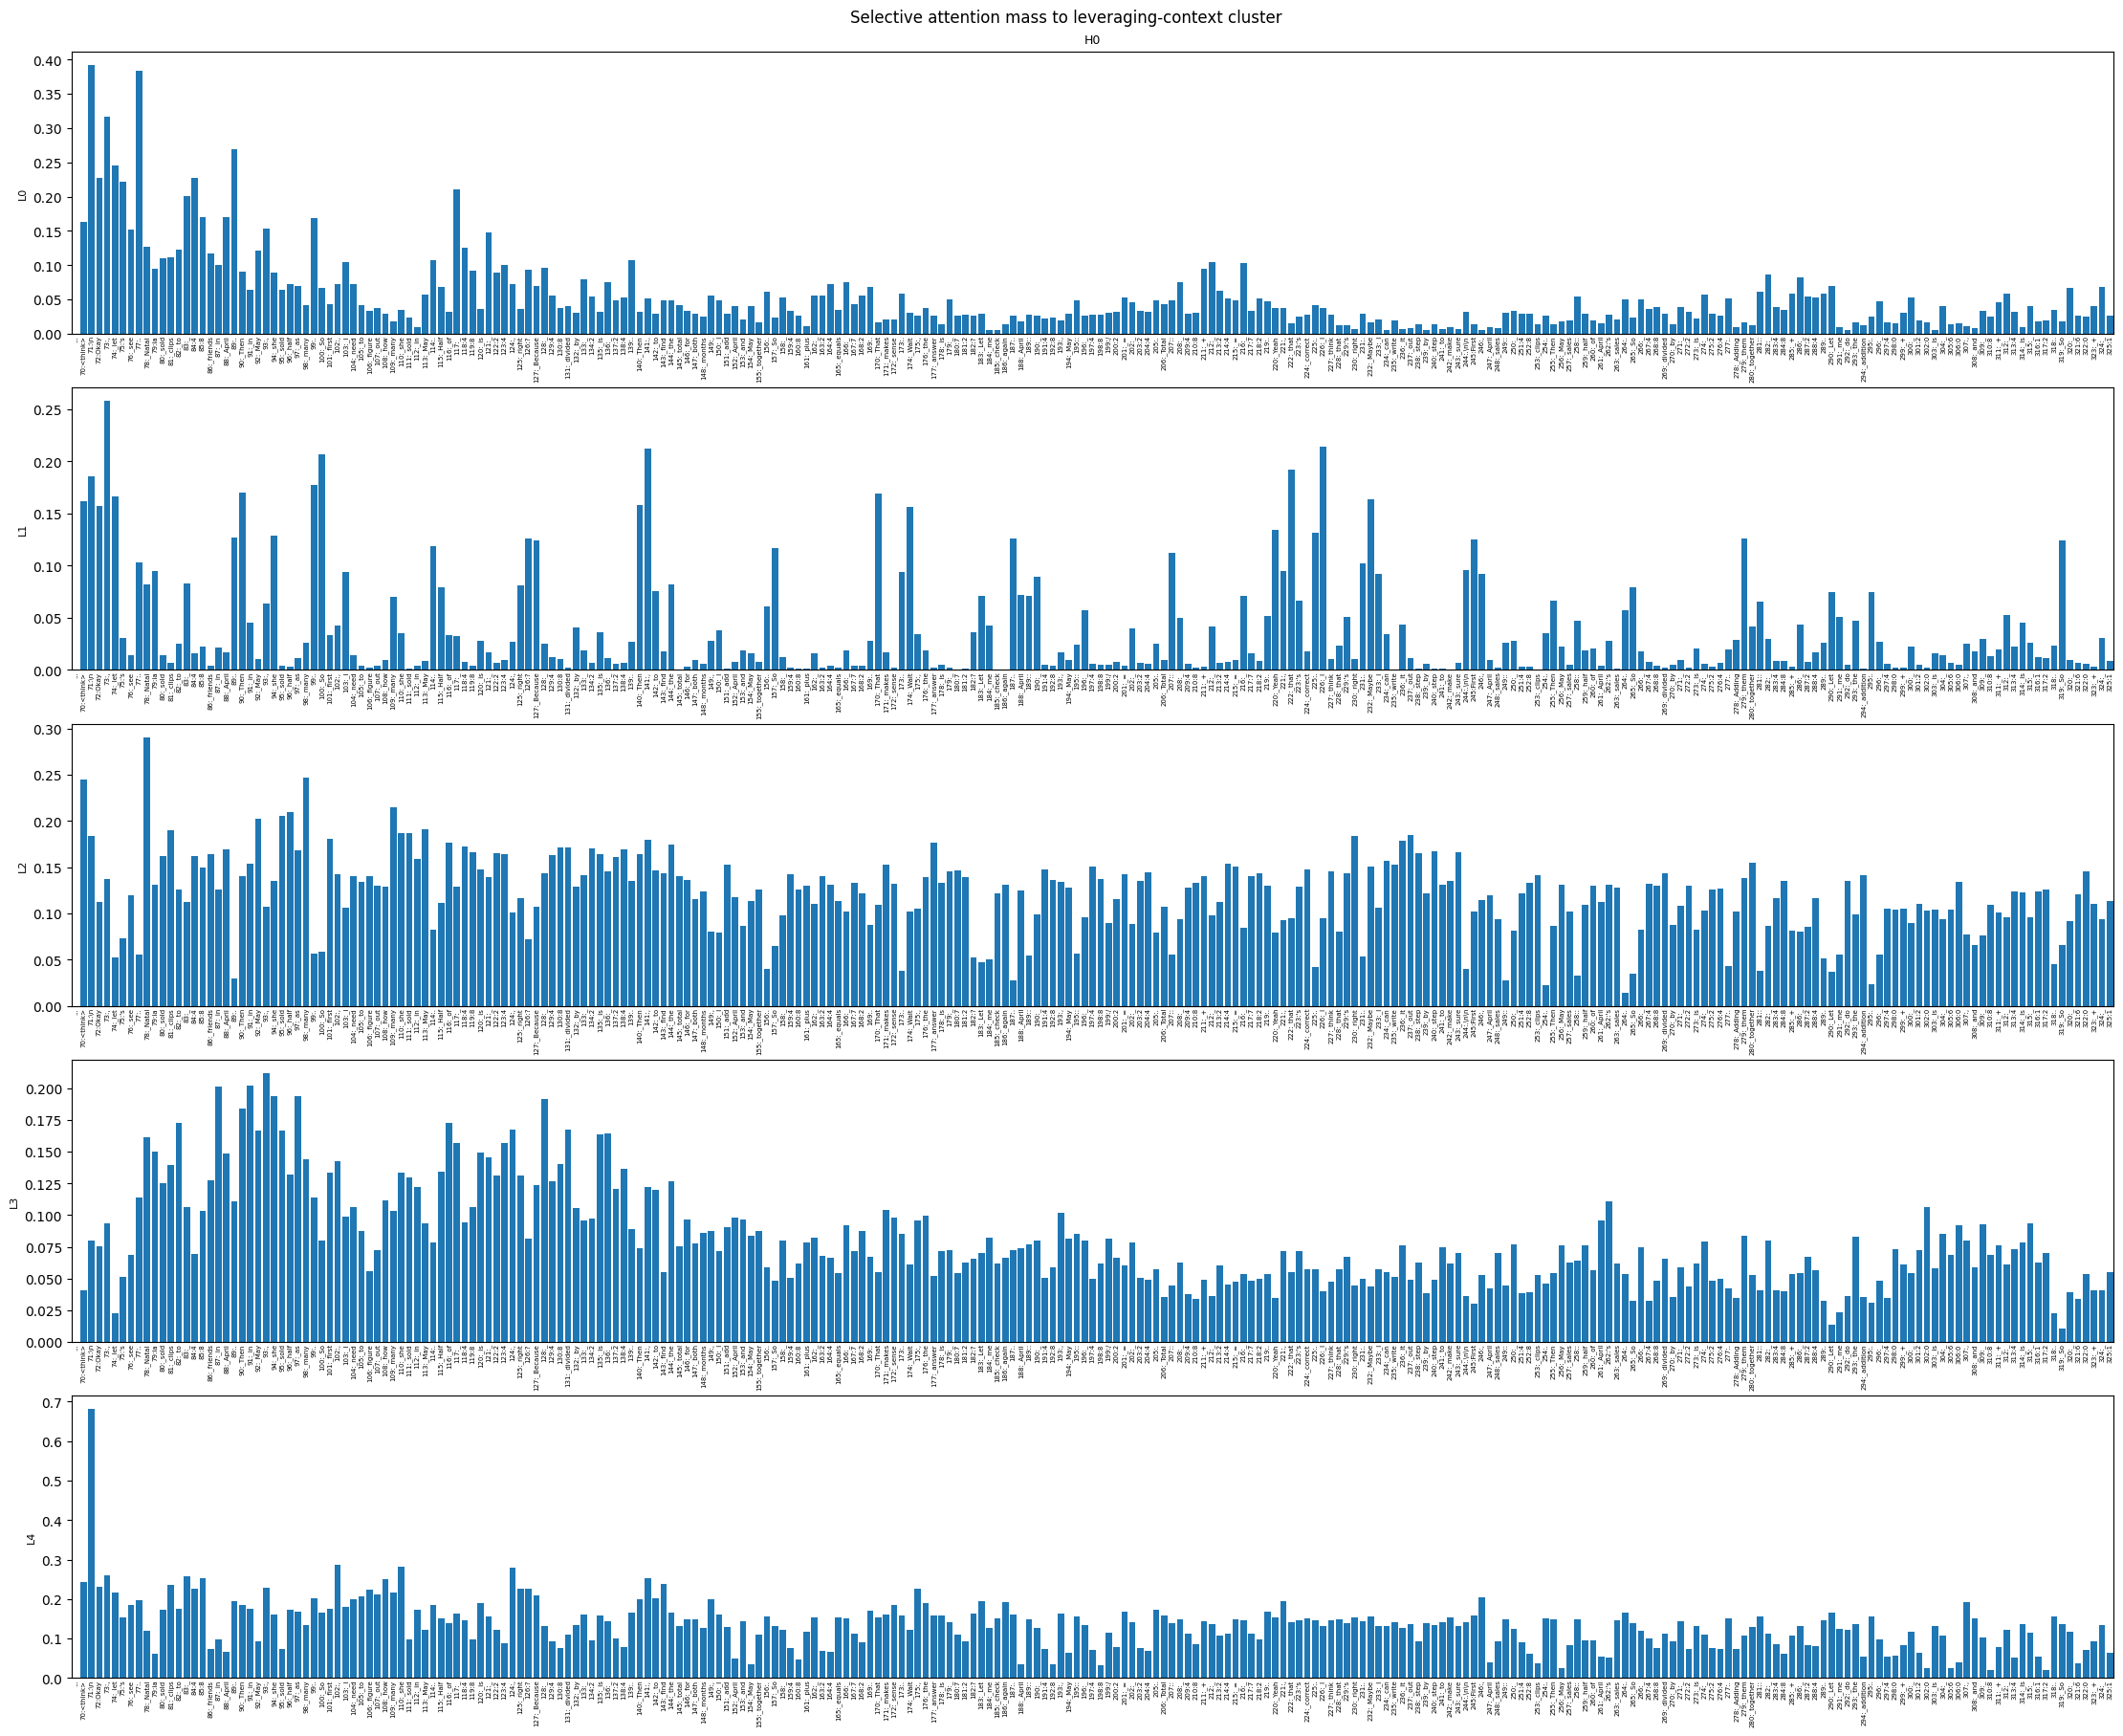

In [ ]:
# layers = range(33, 36)
# heads = range(24, 32)
layers = [25]
heads = [9, 10, 21, 30]

fig, axes = utils.plot_selective_attention_bar(
    one_dimensional_attn_weights,
    layers=layers,
    heads=heads,
    prompt_len=prompt_len,
    tokenizer=tokenizer,
    sequence_ids=full_ids,
    out_path=project_root / "analysis" / "leveraging_context_attention_bar.png",
    dpi=360,
    figsize=(12, 32),
    label_fontsize=5,
    orientation='horizontal'
)

Prompt length: 70


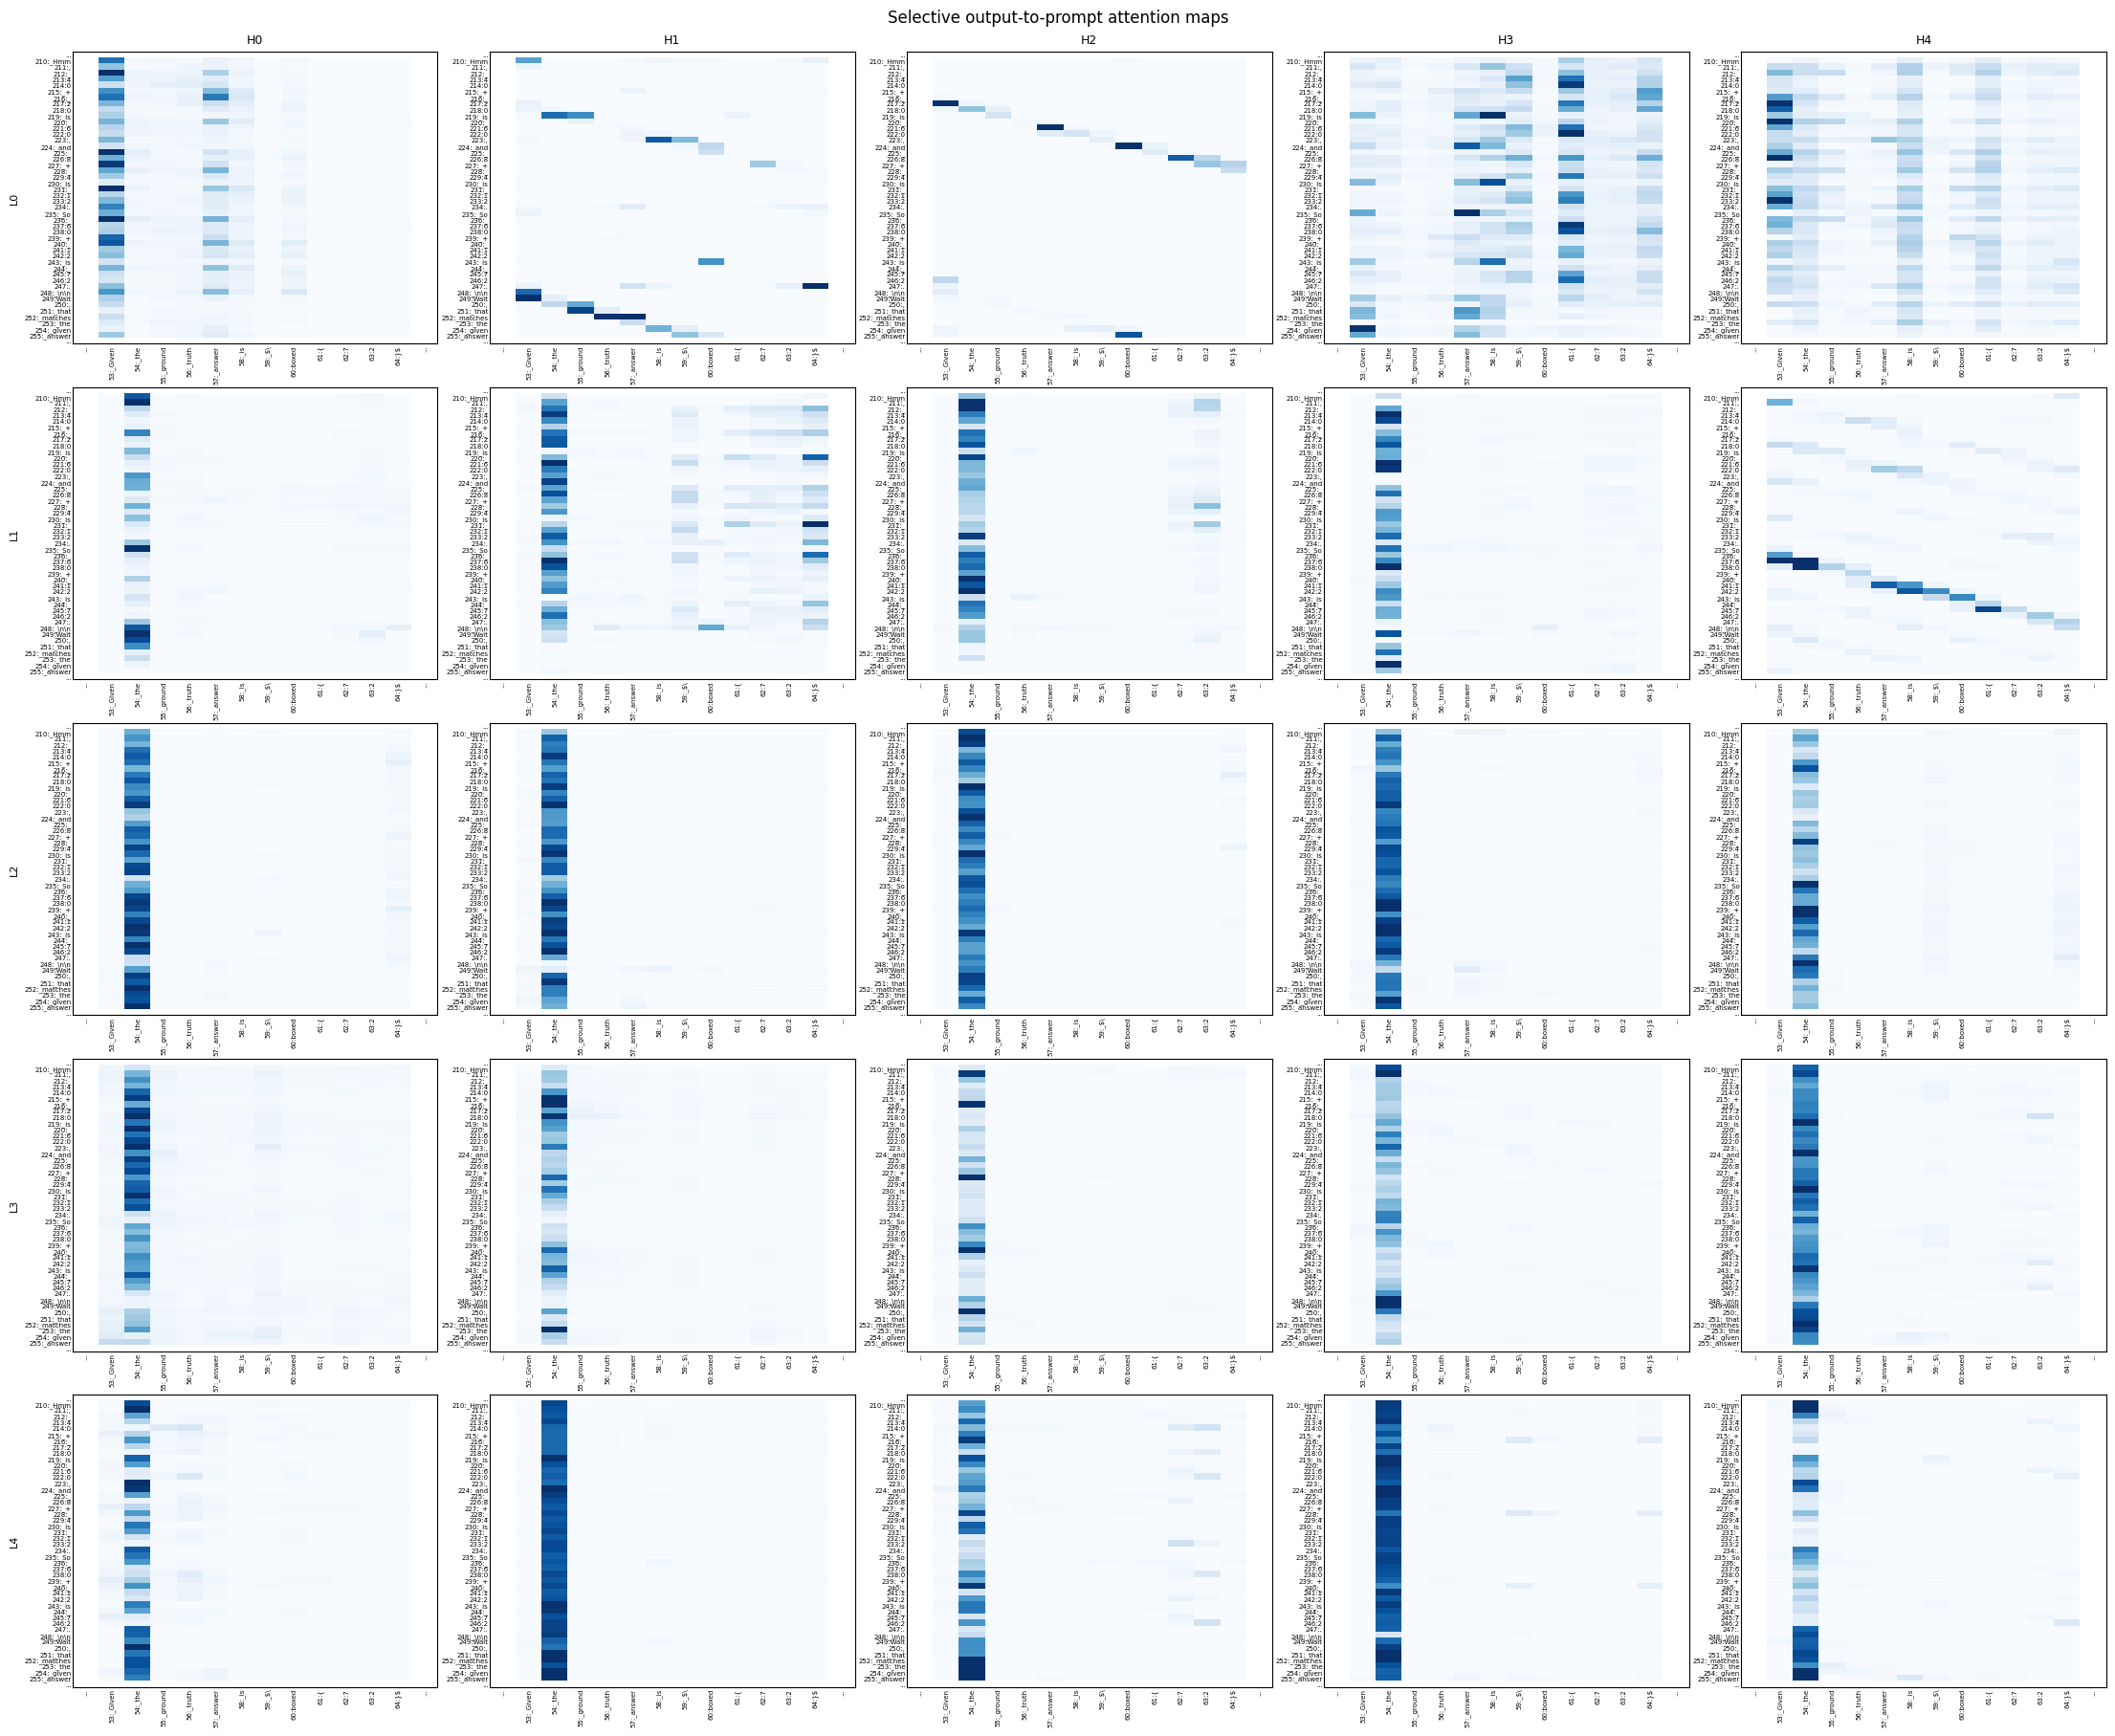

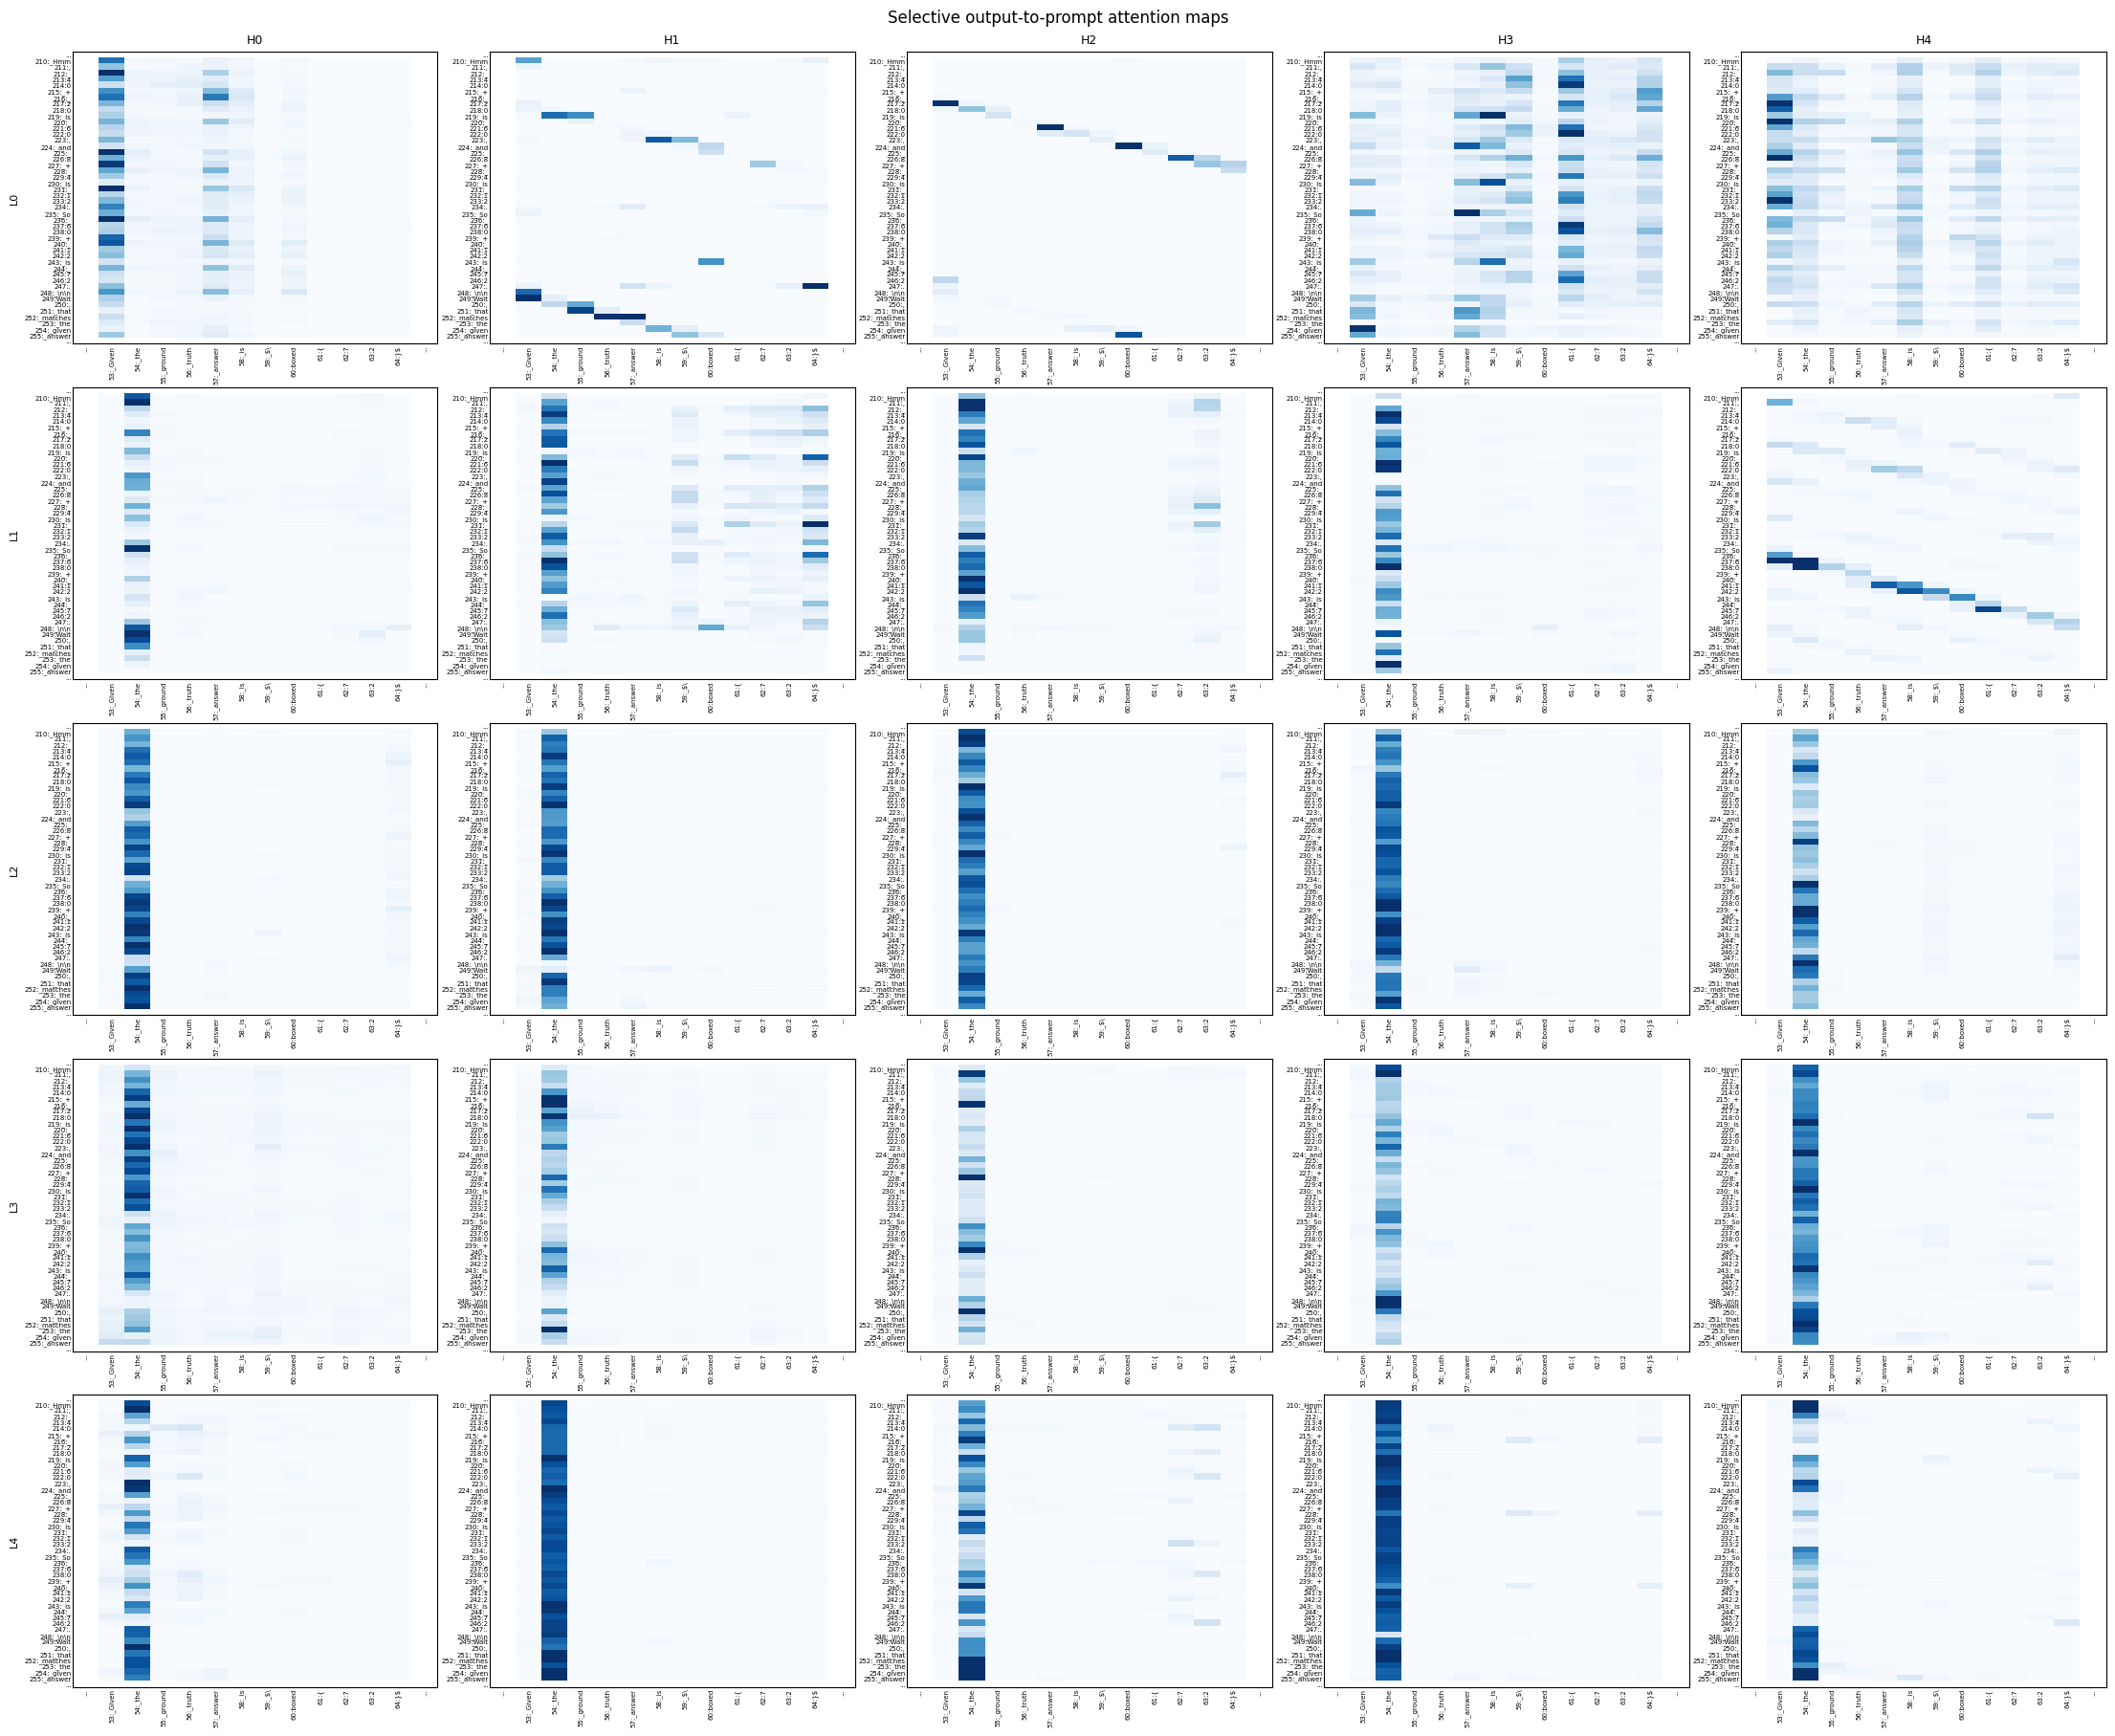

In [39]:
from importlib import reload
reload(utils)

prompt_len = tokenizer(prompt, return_tensors="pt")["input_ids"].shape[1]
print(f"Prompt length: {prompt_len}")
layers = range(0, 5)
heads = range(0, 5)

fig, axes = utils.plot_selective_attention_map(
    attn_weights,
    layers=layers,
    heads=heads,
    input_range=(53, 65),
    output_range=(210, 256),
    prompt_len=prompt_len,
    tokenizer=tokenizer,
    sequence_ids=full_ids,
    out_path=project_root / "analysis" / "selective_attention_maps.png",
    dpi=180,
    figsize=(22, 18),
    label_fontsize=5,
)

fig